In [1]:
import torch
import time
import numpy as np
from tqdm import tqdm
from datasets import load_dataset
from torch.utils.data import DataLoader
from transformers import (
    AutoModel,
    AutoTokenizer,
    AutoProcessor,
    CLIPModel,
    CLIPProcessor
)
from pycocoevalcap.cider.cider import Cider
from pycocoevalcap.spice.spice import Spice
from scipy.spatial.distance import cosine
import matplotlib.pyplot as plt

# Configuration
MODEL_NAME = "Qwen/Qwen2.5-VL-7B-Instruct"
DATASET_NAME = "arampacha/rsicd"
NUM_SOFT_TOKENS = 16
LEARNING_RATE = 1e-3
BATCH_SIZE = 2
GRAD_ACCUM_STEPS = 4
EPOCHS = 3
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Using device: {DEVICE}")

Using device: cuda


In [2]:
from transformers import AutoModel
model = AutoModel.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    trust_remote_code=True  # Required for Qwen models
)

config.json:   0%|          | 0.00/1.37k [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/57.6k [00:00<?, ?B/s]

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

model-00005-of-00005.safetensors:   0%|          | 0.00/1.09G [00:00<?, ?B/s]

model-00003-of-00005.safetensors:   0%|          | 0.00/3.86G [00:00<?, ?B/s]

model-00001-of-00005.safetensors:   0%|          | 0.00/3.90G [00:00<?, ?B/s]

model-00002-of-00005.safetensors:   0%|          | 0.00/3.86G [00:00<?, ?B/s]

model-00004-of-00005.safetensors:   0%|          | 0.00/3.86G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/5 [00:00<?, ?it/s]

In [3]:
processor = AutoProcessor.from_pretrained(MODEL_NAME, trust_remote_code=True)
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)

# Freeze model parameters
for param in model.parameters():
    param.requires_grad = False

preprocessor_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


tokenizer_config.json:   0%|          | 0.00/5.70k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

You have video processor config saved in `preprocessor.json` file which is deprecated. Video processor configs should be saved in their own `video_preprocessor.json` file. You can rename the file or load and save the processor back which renames it automatically. Loading from `preprocessor.json` will be removed in v5.0.


chat_template.json:   0%|          | 0.00/1.05k [00:00<?, ?B/s]

In [54]:
class CoOpAdapter(torch.nn.Module):
    def __init__(self, model, num_tokens=16):
        super().__init__()
        self.model = model
        self.num_tokens = num_tokens
        self.soft_prompt = torch.nn.Parameter(
            torch.randn(1, num_tokens, model.config.hidden_size, 
                        dtype=torch.bfloat16)
        )
    
    def forward(self, pixel_values, input_ids, attention_mask):
        batch_size = input_ids.size(0)

        # 1) get text embeddings from the model’s embedding layer
        text_embeds = self.model.get_input_embeddings()(input_ids)  

        # 2) expand and prepend our soft prompt
        prompt_embeds = self.soft_prompt.expand(batch_size, -1, -1)
        inputs_embeds = torch.cat([prompt_embeds, text_embeds], dim=1)

        # 3) build a new attention mask (1s for soft prompt + original mask)
        prompt_mask = torch.ones(batch_size, self.num_tokens, device=attention_mask.device, dtype=attention_mask.dtype)
        new_attention_mask = torch.cat([prompt_mask, attention_mask], dim=1)

        # 4) call the model in one shot (it knows how to handle pixel_values internally)
        outputs = self.model(
            pixel_values=pixel_values,
            inputs_embeds=inputs_embeds,
            attention_mask=new_attention_mask,
            use_cache=False
        )
        return outputs

coop_adapter = CoOpAdapter(model, NUM_SOFT_TOKENS).to(DEVICE)
optimizer = torch.optim.Adam(coop_adapter.parameters(), lr=LEARNING_RATE)

In [55]:
class RSICDDataset(torch.utils.data.Dataset):
    def __init__(self, dataset_split):
        self.dataset = dataset_split
        self.processor = processor
        self.tokenizer = tokenizer
        
    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, idx):
        example = self.dataset[idx]
        image = example["image"].convert("RGB")
        caption = example["captions"][0]  # Use first caption
        
        # Create prompt with <image> token
        prompt = "<image>\nDescribe this remote sensing image."
        
        # Tokenize text
        text_processed = self.tokenizer(
            prompt,
            return_tensors="pt",
            padding=False,
            truncation=True
        ).input_ids[0]  # Shape: [seq_len]
        
        # Process image
        image_inputs = self.processor(
            images=image,
            return_tensors="pt",
            padding="max_length",
            truncation=True
        )
        image_processed = image_inputs.pixel_values[0]
        
        # Create attention mask
        attention_mask = torch.ones_like(text_processed)
        
        return {
            "pixel_values": image_processed,
            "input_ids": text_processed,
            "attention_mask": attention_mask,
            "caption": caption
        }


In [56]:
dataset = load_dataset(DATASET_NAME)
train_ds = RSICDDataset(dataset["train"])
test_ds = RSICDDataset(dataset["test"])

In [57]:
def collate_fn(batch):
    pixel_values = torch.stack([item["pixel_values"] for item in batch])
    
    # Pad sequences
    input_ids = torch.nn.utils.rnn.pad_sequence(
        [item["input_ids"] for item in batch],
        batch_first=True,
        padding_value=tokenizer.pad_token_id
    )
    
    attention_mask = torch.nn.utils.rnn.pad_sequence(
        [item["attention_mask"] for item in batch],
        batch_first=True,
        padding_value=0
    )
    
    return {
        "pixel_values": pixel_values,
        "input_ids": input_ids,
        "attention_mask": attention_mask,
        "captions": [item["caption"] for item in batch]
    }

# DataLoaders
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, collate_fn=collate_fn, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=1, collate_fn=collate_fn)

In [58]:
# %% [5.1] Final verification
try:
    # Test a single sample
    sample = train_ds[0]
    print("Sample processed successfully!")
    print(f"Pixel values shape: {sample['pixel_values'].shape}")  # Should be [3, 448, 448]
    print(f"Input IDs shape: {sample['input_ids'].shape}")        # Should be [seq_len]
    print(f"Attention mask shape: {sample['attention_mask'].shape}") # Should be [seq_len]
    
    # Test if the tokenizer recognizes <image> token
    print("\nDecoded input IDs:")
    print(tokenizer.decode(sample["input_ids"]))
    
    # Test batch creation
    test_batch = next(iter(train_loader))
    print("\nBatch created successfully!")
    print(f"Batch pixel values shape: {test_batch['pixel_values'].shape}")  # [batch, 3, H, W]
    print(f"Batch input IDs shape: {test_batch['input_ids'].shape}")        # [batch, max_seq_len]
    print(f"Batch attention mask shape: {test_batch['attention_mask'].shape}")
    
except Exception as e:
    print(f"Error: {str(e)}")
    import traceback
    traceback.print_exc()

Error: argument of type 'NoneType' is not iterable


Traceback (most recent call last):
  File "/tmp/ipykernel_1706/350160296.py", line 4, in <module>
    sample = train_ds[0]
  File "/tmp/ipykernel_1706/669370342.py", line 27, in __getitem__
    image_inputs = self.processor(
  File "/workspace/venv/lib/python3.10/site-packages/transformers/models/qwen2_5_vl/processing_qwen2_5_vl.py", line 174, in __call__
    while self.image_token in text[i]:
TypeError: argument of type 'NoneType' is not iterable


In [59]:
from tqdm import tqdm
import matplotlib.pyplot as plt
import sys

coop_adapter.train()
optimizer = torch.optim.Adam(coop_adapter.parameters(), lr=LEARNING_RATE)
total_loss = 0
loss_history = []

# Train for one epoch only
for i, batch in enumerate(tqdm(train_loader, desc="Training (1 epoch)")):
    try:
        # Move batch to device
        pixel_values = batch["pixel_values"].to(DEVICE)
        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        
        # Forward pass
        outputs = coop_adapter(
            pixel_values=pixel_values,
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        
        # Calculate loss
        loss = outputs.loss
        total_loss += loss.item()
        
        # Backward pass
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        
        # Record loss every 50 steps
        if i % 50 == 0:
            avg_loss = total_loss / (i + 1)
            loss_history.append(avg_loss)
            print(f"Step {i}/{len(train_loader)} - Loss: {avg_loss:.4f}")
            
    except Exception as e:
        print(f"\nError at batch {i}: {str(e)}")
        print("Batch contents:")
        for k, v in batch.items():
            if isinstance(v, torch.Tensor):
                print(f"  {k}: shape={v.shape}, dtype={v.dtype}")
            else:
                print(f"  {k}: type={type(v)}")
        print("Skipping batch...")
        continue

# Final loss
if len(train_loader) > 0:
    avg_loss = total_loss / len(train_loader)
    print(f"\nEpoch Complete! Average Loss: {avg_loss:.4f}")
else:
    print("\nTraining failed - no batches processed")
    sys.exit(1)

Training (1 epoch):   0%|          | 0/4367 [00:00<?, ?it/s]


TypeError: argument of type 'NoneType' is not iterable

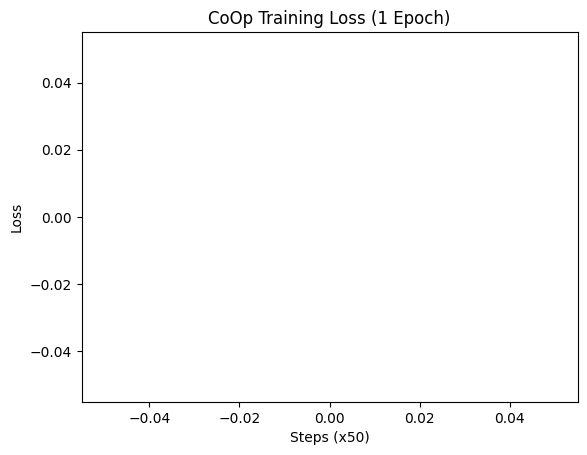

In [47]:
plt.plot(loss_history)
plt.title("CoOp Training Loss (1 Epoch)")
plt.xlabel("Steps (x50)")
plt.ylabel("Loss")
plt.show()